In [1]:
from THM_main import Version5_THM_prototype
from iapws import IAPWS97
import numpy as np
from THM_main import plotting
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
# Begining of the script used to test the THM prototype class.

In [2]:
def guess_power_density_sine(Ptot, h, r, num_control_volumes): # New version, supposed to be more accurate but introduced alot of instability in the TH solution
    """
    Compute the power density in a cylinder with a sine-shaped profile along the axial direction.

    Parameters:
    Ptot (float): Total power released in the cylinder [W].
    h (float): Total height of the cylinder [m].
    r (float): Radius of the cylinder [m].
    num_control_volumes (int): Number of control volumes along the z-axis.

    Returns:
    z_values (numpy array): Array of z positions (center of each control volume) along the height of the cylinder.
    power_density (numpy array): Array of power densities corresponding to each control volume.
    q0 (float): The peak power density constant.
    """
    
    # Cross-sectional area of the cylinder
    A_cross_section = np.pi * r**2

    # Function for the power density profile along the axial direction
    def q(z, q0):
        return q0 * np.sin(np.pi * z / h)

    # Calculate q0 to ensure total power matches Ptot
    q0 = Ptot / (A_cross_section * (2 * h / np.pi))  # derived from the integral

    # Compute the boundaries and midpoints of each control volume
    z_boundaries = np.linspace(0, h, num_control_volumes + 1)
    z_values = (z_boundaries[:-1] + z_boundaries[1:]) / 2  # Midpoints of control volumes

    # Compute power density at each midpoint
    power_density = q(z_values, q0)

    return z_values, power_density

In [3]:
compute_case_monophasic = True
if compute_case_monophasic:
    case_name = "genfoam_comparaison_correl"
    #User choice:
    solveConduction = False
    plot_at_z1 = [0.8]

    ########## Thermal hydraulics parameters ##########
    ## Geometric parameters
    canalType = "square"
    waterRadius = 0.0133409 # m
    fuelRadius = 0.00542310/2 # m : fuel rod radius
    gapRadius = fuelRadius + 0.0000000001  # m : expansion gap radius : "void" between fuel and clad - equivalent to inner clad radius
    cladRadius =  0.0094996/2 # m : clad external radius
    height = 1.855 # m : height : active core height in BWRX-300 SMR

    ## Fluid parameters
    pOutlet = 14719781.65 # Pa
    tInlet = 592.75 #K
    u_inlet = 4.467092221 #m/s
    pressureDrop = 186737 #Pa/m
    falsePInlet = pOutlet - height * pressureDrop
    rhoInlet = IAPWS97(T = tInlet, P = falsePInlet*10**(-6)).rho #kg/m3
    flowArea = waterRadius ** 2 - np.pi * cladRadius ** 2
    qFlow = u_inlet * rhoInlet * flowArea # kg/m^2/s
    
    ## Meshing parameters:
    If = 8
    I1 = 3
    Iz1 = 75 # number of control volumes in the axial direction

    ## Thermalhydraulics correlation
    voidFractionCorrel = "EPRIvoidModel"
    frfaccorel = "blasius"
    P2Pcorel = "lockhartMartinelli"
    numericalMethod = 'FVM'

    ############ Nuclear Parameters ###########
    ## Fission parameters
    qFiss = 1943301220 # W/m3
    #qFiss = 1943301220 * height * np.pi * fuelRadius ** 2 # W
    ## Material parameters
    kFuel = 4.18 # W/m.K, TECHNICAL REPORTS SERIES No. 59 : Thermal Conductivity of Uranium Dioxide, IAEA, VIENNA, 1966
    Hgap = 10000
    kClad = 21.5 # W/m.K, Thermal Conductivity of Zircaloy-2 (as used in BWRX-300) according to https://www.matweb.com/search/datasheet.aspx?MatGUID=eb1dad5ce1ad4a1f9e92f86d5b44740d
    # k_Zircaloy-4 = 21.6 W/m.K too so check for ATRIUM-10 clad material but should have the same thermal conductivity
    ########## Algorithm parameters ###########
    nIter = 1000
    tol = 1e-4

    z, p = guess_power_density_sine(qFiss, height, fuelRadius, Iz1-5)

    Iz1 = 75
    Qfiss1 = []
    for i in range(Iz1): 
        if i*(height/Iz1) < 0.1:
            Qfiss1.append(0)
        else:
            Qfiss1.append(qFiss)
            #Qfiss1.append(p[i-5])
    print(Qfiss1)

    case0 = Version5_THM_prototype(case_name, canalType,
                 waterRadius, fuelRadius, gapRadius, cladRadius, height, tInlet, pOutlet, qFlow, Qfiss1,
                 kFuel, Hgap, kClad, Iz1, If, I1, plot_at_z1, solveConduction,
                 dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = voidFractionCorrel, numericalMethod = numericalMethod)
    

[0, 0, 0, 0, 0, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220]
$$$---------- THM: prototype, case treated : genfoam_comparaison_correl.
$$$---------- THM: prototype, steady state case.
$$---------- Calling D

In [4]:
class GFPlotter():
    def __init__(self, caseList, directory_path, case_name):
        self.case_name = f'{case_name}\\'

        self.caseList = caseList
        self.directory_path = directory_path
        self.height = self.caseList[0].convection_sol.height

        self.data_dict_list = []
        self.data_dict = self.read_files_in_directory()
        self.allow_space()

        self.struture_fraction = 1 - (self.alpha_liquid[0] + self.alpha_vapour[0])

        self.calculateFields()
        self.createZ()

    def createZ(self):
        self.zList = np.linspace(0, self.height, len(self.alpha_liquid))

    def read_files_in_directory(self):
        data_dict = {}
        print(f"Reading files in directory: {self.directory_path}")
        # Parcourt tous les fichiers du dossier
        for filename in os.listdir(self.directory_path):
            file_path = os.path.join(self.directory_path, filename)
            print(f"Reading file: {file_path}")
            # Vérifie que c'est bien un fichier
            if os.path.isfile(file_path):

                with open(file_path, 'r') as file:
                    content = file.read()
                    
                    # Trouve la première parenthèse ouvrante et fermante
                    start = content.find('(')
                    end = content.find(')', start)
                    
                    if start != -1 and end != -1:
                        # Extrait les données entre les parenthèses
                        data_str = content[start+1:end].strip()
                        # Divise les lignes en liste de chaînes
                        data_lines = data_str.splitlines()
                        if len(data_lines) != 1:
                            float_list = [float(item) for item in data_lines]
                            data_dict[filename] = float_list

                    if len(data_lines) == 1:
                        # Trouve la première parenthèse ouvrante et fermante
                        start = content.find('(')
                        end = content.find(';', start)
                        if start != -1 and end != -1:
                            # Extrait les données entre les parenthèses
                            data_str = content[start+1:end].strip()
                            # Divise les lignes en liste de chaînes
                            data_lines = data_str.splitlines()
                            data_lines.pop()
                            print(data_lines)
                            x, y, z = np.zeros(len(data_lines)), np.zeros(len(data_lines)), np.zeros(len(data_lines))
                            for i in range(len(data_lines)):
                                a = values = data_lines[i].strip("()").split()
                                x[i] = float(a[0])
                                y[i] = float(a[1])
                                z[i] = float(a[2])
                            data_dict[fr'{filename}_x'] = x
                            data_dict[fr'{filename}_y'] = y
                            data_dict[fr'{filename}_z'] = z
        
        return data_dict
    
    def allow_space(self):
        self.alpha_liquid = np.array(self.data_dict['alpha.liquid'])
        self.alpha_vapour = np.array(self.data_dict['alpha.vapour'])
        self.alpha_powerModel = np.array(self.data_dict['alpha.powerModel'])
        self.alphaPhi_liquid = np.array(self.data_dict['alphaPhi.liquid']+ [self.data_dict['alphaPhi.liquid'][-1]])
        self.alphaPhi_vapour = np.array(self.data_dict['alphaPhi.vapour']+ [self.data_dict['alphaPhi.vapour'][-1]])
        self.alphaRhoMagU_liquid = np.array(self.data_dict['alphaRhoMagU.liquid']+ [self.data_dict['alphaRhoMagU.liquid'][-1]])
        self.alphaRhoMagU_vapour = np.array(self.data_dict['alphaRhoMagU.vapour']+ [self.data_dict['alphaRhoMagU.vapour'][-1]])
        self.alphaRhoPhi_liquid = np.array(self.data_dict['alphaRhoPhi.liquid']+ [self.data_dict['alphaRhoPhi.liquid'][-1]])
        self.alphaRhoPhi_vapour = np.array(self.data_dict['alphaRhoPhi.vapour']+ [self.data_dict['alphaRhoPhi.vapour'][-1]])
        self.areaDensity_interface = np.array(self.data_dict['areaDensity.interface'])
        self.dgdt_liquid = np.array(self.data_dict['dgdt.liquid'])
        self.dgdt_vapour = np.array(self.data_dict['dgdt.vapour'])
        self.dmdt_vapour = np.array(self.data_dict['dmdt.liquid.vapour'])
        self.heatFlux_structure = np.array(self.data_dict['heatFlux.structure'])
        self.htc_liquid_interface = np.array(self.data_dict['htc.liquid.interface'])
        self.htc_liquid_structure = np.array(self.data_dict['htc.liquid.structure'])
        self.p = np.array(self.data_dict['p'])
        self.p_rgh = np.array(self.data_dict['p_rgh'])
        self.Re_liquid_structure = np.array(self.data_dict['Re.liquid.structure'])
        self.Re_vapour_structure = np.array(self.data_dict['Re.vapour.structure'])
        self.Re_liquid_vapour = np.array(self.data_dict['Re.liquid.vapour'])
        self.T_fixedPower = np.array(self.data_dict['T.fixedPower'])
        self.T_liquid = np.array(self.data_dict['T.liquid'])
        self.T_vapour = np.array(self.data_dict['T.vapour'])
        self.U_liquid_x = np.array(self.data_dict['U.liquid_x'])
        self.U_liquid_y = np.array(self.data_dict['U.liquid_y'])
        self.U_liquid_z = np.array(self.data_dict['U.liquid_z'])
        self.U_vapour_x = np.array(self.data_dict['U.vapour_x'])
        self.U_vapour_y = np.array(self.data_dict['U.vapour_y'])
        self.U_vapour_z = np.array(self.data_dict['U.vapour_z'])

    def calculateFields(self):
        self.alpha_vapour = self.alpha_vapour/(1-self.struture_fraction)
        self.alpha_liquid = self.alpha_liquid/(1-self.struture_fraction)
        self.U_liquid = np.sqrt(self.U_liquid_x**2 + self.U_liquid_y**2 + self.U_liquid_z**2)
        self.U_vapour = np.sqrt(self.U_vapour_x**2 + self.U_vapour_y**2 + self.U_vapour_z**2)
        self.U_mixture = (1-self.alpha_vapour) * self.U_liquid + self.alpha_vapour * self.U_vapour

        self.rho_liquid  = self.alphaRhoPhi_liquid/(self.alphaPhi_liquid)
        self.rho_vapour = self.alphaRhoPhi_vapour/(self.alphaPhi_vapour)
        for i in range(len(self.rho_vapour)):
            if np.isnan(self.rho_vapour[i]):
                self.rho_vapour[i] = 0
            if np.isnan(self.rho_liquid[i]):
                self.rho_liquid[i] = 0
        print(f"rho_liquid: {self.rho_liquid}")
        print(f"rho_vapour: {self.rho_vapour}")
        self.rho_mixture = self.rho_liquid + self.rho_vapour
    def plotComparison(self):
        file_path = rf'C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\result\{self.case_name}'
        os.makedirs(os.path.dirname(file_path), exist_ok=True)
        if len(self.caseList) == 1:
            labelTitle = 'DFM'
        title = f"f: {self.caseList[0].convection_sol.frfaccorel}, \n Méthode numérique: {self.caseList[0].convection_sol.numericalMethod}, \n Correlation void fraction: {self.caseList[0].convection_sol.voidFractionCorrel}"
        fig1, ax1 = plt.subplots()
        for i in range(len(self.caseList)):
            ax1.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.T_water, label=labelTitle)
        ax1.step(self.zList, self.T_liquid, label="GenFoam")
        ax1.step(self.zList, self.T_vapour, label="GenFoam")
        ax1.set_xlabel("Axial position in m")
        ax1.set_ylabel("Temperature in K")
        ax1.set_title(f"{title}")
        ax1.grid()
        ax1.legend(loc="best")
        fig1.savefig(rf'result\{self.case_name}\Tcoolant.png', bbox_inches='tight')

        fig2, ax2 = plt.subplots()
        for i in range(len(self.caseList)):
            ax2.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.voidFraction[-1], label=labelTitle)
        ax2.step(self.zList, self.alpha_vapour, label="GenFoam")
        ax2.set_xlabel("Axial position in m")
        ax2.set_ylabel("Void fraction")
        ax2.set_title(f"{title}")
        ax2.grid()
        ax2.legend(loc="best")
        fig2.savefig(rf'result\{self.case_name}\epsilon.png', bbox_inches='tight')

        fig3, ax3 = plt.subplots()
        print(f"rho_mix: {self.rho_mixture}")
        for i in range(len(self.caseList)):
            ax3.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rho[-1], label=labelTitle)
        ax3.plot(self.zList, self.rho_mixture, label="GenFoam")
        ax3.set_xlabel("Axial position in m")
        ax3.set_ylabel("Density in kg/m^3")
        ax3.set_title(f"{title}")
        ax3.grid()
        ax3.legend(loc="best")
        fig3.savefig(rf'result\{self.case_name}\Rho.png', bbox_inches='tight')

        fig7, ax7 = plt.subplots()
        for i in range(len(self.caseList)):
            ax7.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoL[-1], label=labelTitle)
        ax7.plot(self.zList, self.rho_liquid, label="GenFoam")
        ax7.set_xlabel("Axial position in m")
        ax7.set_ylabel("Liquid density in kg/m^3")
        ax7.set_title(f"{title}")
        ax7.grid()
        ax7.legend(loc="best")
        fig7.savefig(rf'result\{self.case_name}\RhoL.png', bbox_inches='tight')

        fig8, ax8 = plt.subplots()
        for i in range(len(self.caseList)):
            ax8.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoG[-1], label=labelTitle)
        ax8.plot(self.zList, self.rho_vapour, label="GenFoam")
        ax8.set_xlabel("Axial position in m")
        ax8.set_ylabel("Vapour density in kg/m^3")
        ax8.set_title(f"{title}")
        ax8.grid()
        ax8.legend(loc="best")
        fig8.savefig(rf'result\{self.case_name}\RhoG.png', bbox_inches='tight')

        fig4, ax4 = plt.subplots() 
        for i in range(len(self.caseList)):
            ax4.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.P[-1], label=labelTitle)
        ax4.step(self.zList, self.p, label="GenFoam")
        ax4.set_xlabel("Axial position in m")
        ax4.set_ylabel("Pressure in Pa")
        ax4.grid()
        ax4.set_title(f"{title}")
        ax4.legend(loc="best")
        fig4.savefig(rf'result\{self.case_name}\P.png', bbox_inches='tight')

        fig5, ax5 = plt.subplots()
        for i in range(len(self.caseList)):
            ax5.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ul, label=labelTitle)
        ax5.step(self.zList, self.U_liquid, label="GenFoam")
        ax5.set_xlabel("Axial position in m")
        ax5.set_ylabel("Liquid Velocity in m/s")
        ax5.set_title(f"{title}")
        ax5.grid()
        ax5.legend(loc="best")
        fig5.savefig(rf'result\{self.case_name}\Ul.png', bbox_inches='tight')

        fig6, ax6 = plt.subplots()
        for i in range(len(self.caseList)):
            ax6.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ug, label=labelTitle)
        ax6.step(self.zList, self.U_vapour, label="GenFoam")
        ax6.set_xlabel("Axial position in m")
        ax6.set_ylabel("Vapour Velocity in m/s")
        ax6.set_title(f"{title}")
        ax6.grid()
        ax6.legend(loc="best")
        fig6.savefig(rf'result\{self.case_name}\Ug.png', bbox_inches='tight')

        fig9, ax9 = plt.subplots()
        for i in range(len(self.caseList)):
            ax9.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.U[-1], label=labelTitle)
        ax9.step(self.zList, self.U_mixture, label="GenFoam")
        ax9.set_xlabel("Axial position in m")
        ax9.set_ylabel("Mixture Velocity in m/s")
        ax9.set_title(f"{title}")
        ax9.grid()
        ax9.legend(loc="best")
        fig9.savefig(rf'result\{self.case_name}\U.png', bbox_inches='tight')

        fig10, ax10 = plt.subplots()
        for i in range(len(self.caseList)):
            ax10.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Rel, label=labelTitle)
        ax10.step(self.zList, self.Re_liquid_structure, label="GenFoam")
        ax10.set_xlabel("Axial position in m")
        ax10.set_ylabel("Reynolds number")
        ax10.set_title(f"{title}")
        ax10.grid()
        ax10.legend(loc="best")
        fig10.savefig(rf'result\{self.case_name}\Re.png', bbox_inches='tight')

        fig11, ax11 = plt.subplots()
        ax11.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.xTh[-1], label=labelTitle)
        ax11.set_xlabel("Axial position in m")
        ax11.set_ylabel("xTh")
        ax11.set_title(f"{title}")
        ax11.grid()
        ax11.legend(loc="best")
        fig11.savefig(rf'result\{self.case_name}\xTh.png', bbox_inches='tight')


        plt.show()


Reading files in directory: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\fluidRegion_chgMesh
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\fluidRegion_chgMesh\alpha.liquid
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\fluidRegion_chgMesh\alpha.passiveStructure
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\fluidRegion_chgMesh\alpha.powerModel
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\fluidRegion_chgMesh\alpha.structure
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\fluidRegion_chgMesh\alpha.vapour
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\fluidRegion_chgMesh\alphaPhi.liquid
Reading file: C:\Users\cleme\OneDr

C:\Users\cleme\AppData\Local\Temp\ipykernel_16324\3972825620.py:110: RuntimeWarning: invalid value encountered in divide
  self.rho_vapour = self.alphaRhoPhi_vapour/(self.alphaPhi_vapour)


rho_mix: [678.41785688 678.41901492 678.41797129 678.41692765 678.4180857
 660.51472137 660.52936625 660.52885616 660.53638476 660.53723858
 660.5368273  660.53473452 660.53508725 660.53769336 660.53795967
 660.53859049 660.53932681 660.54098371 660.54189593 660.54119815
 660.54152642 660.54391741 660.54480419 660.54662947 660.55062053
 660.55239748 660.55756433 660.56254345 660.56718887 660.57089965
 677.0557695  675.68694505 674.31598098 672.93651816 671.55941493
 670.17183893 668.78141326 667.39140152 665.99336039 664.59587835
 663.19265985 661.79012619 660.37992159 658.97054373 657.55781765
 656.14082447 654.72484104 653.30570505 651.88564799 650.46256679
 649.03761065 647.61594944 646.18942071 644.7642784  643.33639055
 641.90998538 640.48093982 639.05041426 637.62541143 636.19900413
 634.76821695 633.34302925 631.91547252 630.48973239 629.06662493
 679.71621819 678.36753396 677.0876173  675.87561864 674.72086297
 673.62794886 672.59048557 671.60695531 670.67628236 669.79885269
 6

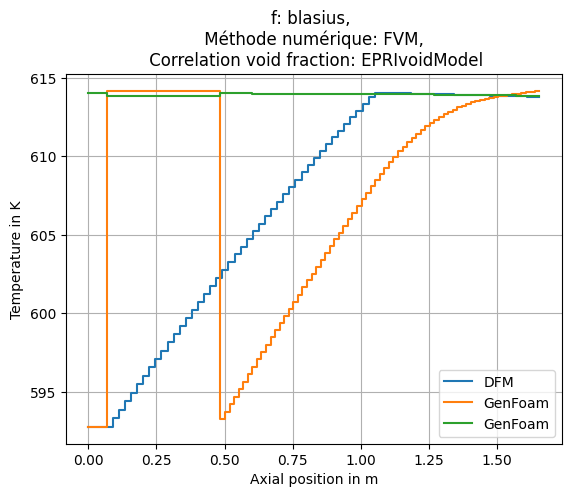

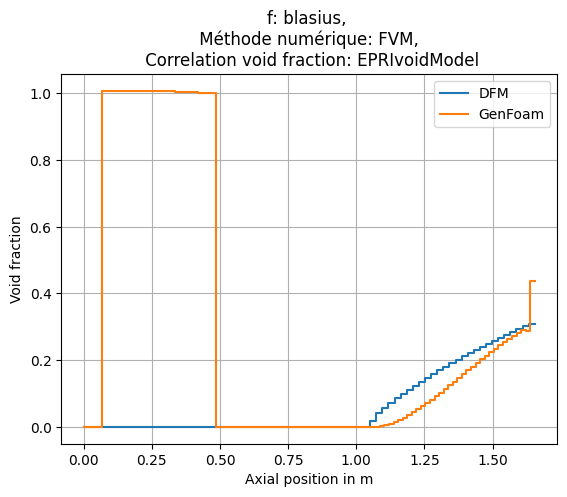

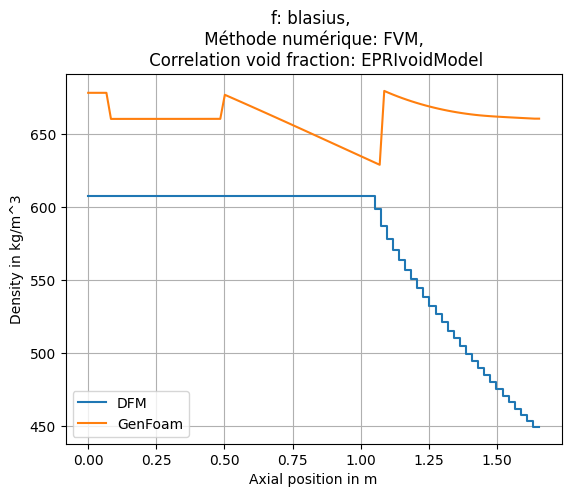

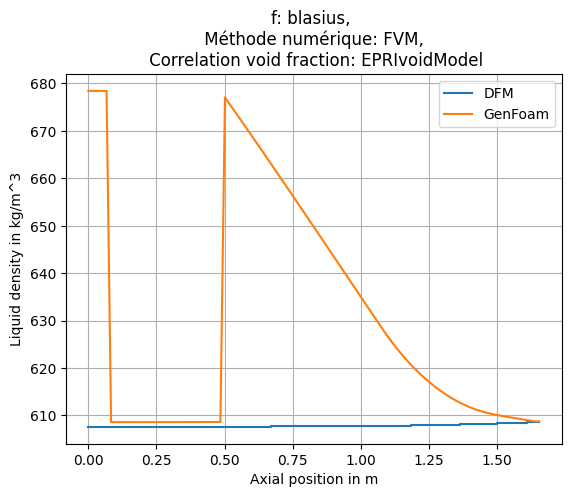

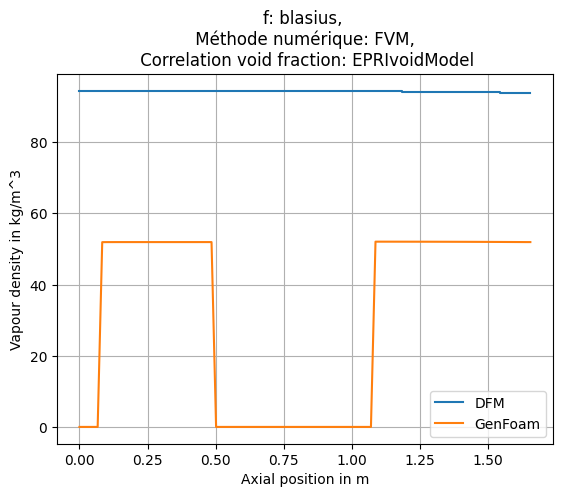

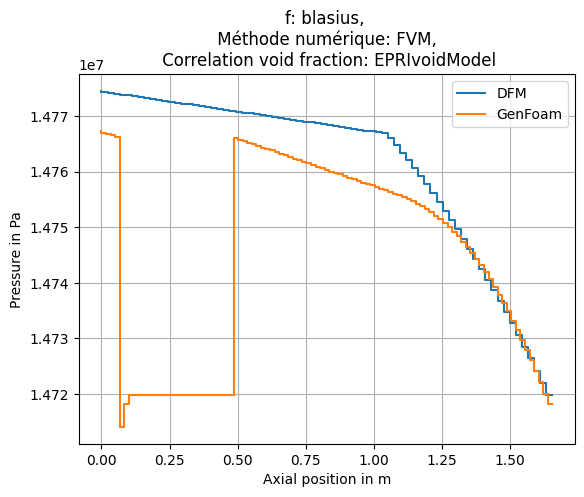

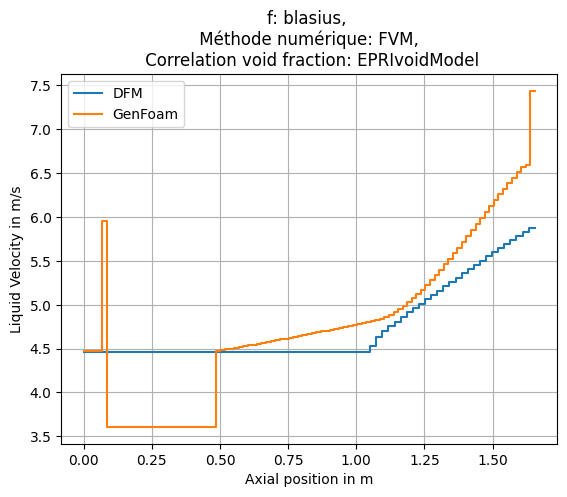

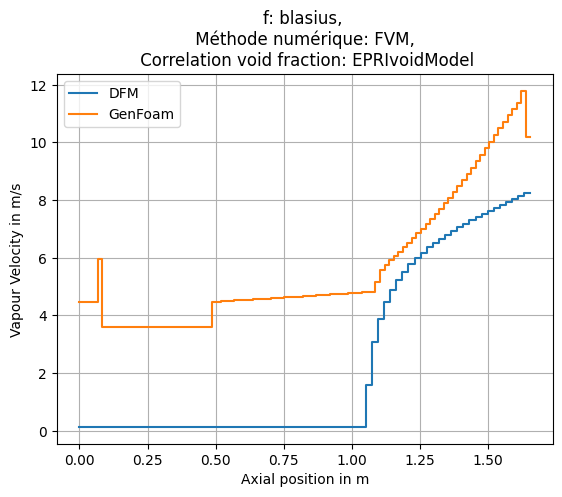

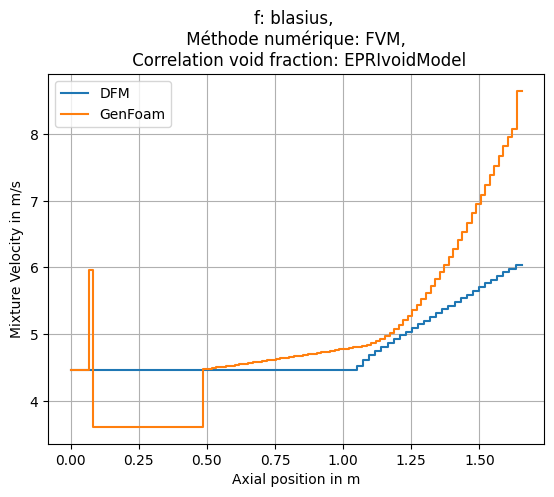

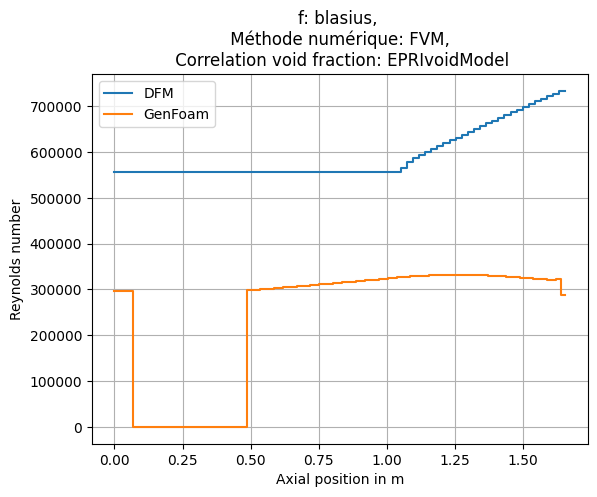

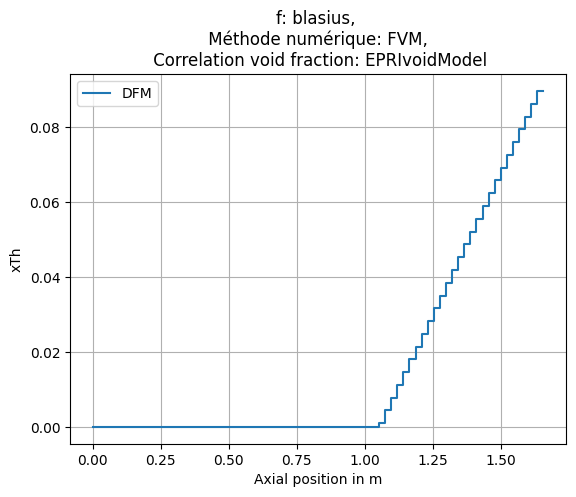

Umixture: [4.46708    4.46706    4.46704    4.46702    4.46701    5.95466
 3.60730993 3.60703    3.60696    3.60698    3.607      3.60701
 3.60703    3.60704    3.60706    3.60707    3.60709    3.6071
 3.60711    3.60713    3.60714    3.60715    3.60717    3.60718
 3.60719    3.6072     3.60722    3.60723    3.60724    3.60725
 4.47149    4.4805     4.48959    4.49874    4.50795    4.51723
 4.52658    4.53599    4.54546    4.555      4.5646     4.57426
 4.58398    4.59376    4.60359    4.61349    4.62345    4.63346
 4.64353    4.65365    4.66383    4.67406    4.68434    4.69467
 4.70506    4.7155     4.72599    4.73652    4.74711    4.75774
 4.76842    4.77914    4.78991    4.80072    4.81158    4.82248001
 4.83735299 4.86071989 4.8910671  4.92796003 4.97132981 5.02083198
 5.0762081  5.13729863 5.20395921 5.27606446 5.35352074 5.43624435
 5.52415687 5.61715448 5.7151504  5.8180432  5.92571263 6.0380341
 6.15484601 6.27601827 6.40225035 6.53356432 6.66877813 6.80692696
 6.9474961  7.090

In [5]:
plotter = GFPlotter([case0], rf'C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\fluidRegion_chgMesh', "Phase_Ex1_12223_chgMesh")
plotter.plotComparison()
print(f'Umixture: {plotter.U_mixture}')